# Online Retail II — Data Understanding

## Customer Intelligence Analytics

This notebook explores the cleaned Online Retail II transaction data before
customer segmentation, churn prediction, and customer lifetime value modeling.

### Objectives

- Verify the cleaned dataset and its analytical scope.
- Understand transactions, invoices, customers, products, and countries.
- Analyze revenue patterns and seasonality.
- Investigate cancellations, returns, and reversals.
- Create initial customer-level business metrics.
- Produce reusable summaries and figures for the final report.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "transactions_clean.parquet"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Clean dataset was not found: {DATA_PATH}"
    )


print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_PATH}")

Project root: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics
Dataset:      c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\transactions_clean.parquet


In [3]:
COLUMNS = [
    "invoice",
    "stock_code",
    "description",
    "quantity",
    "invoice_date",
    "unit_price",
    "customer_id",
    "country",
    "source_period",
    "line_amount",
    "has_customer_id",
    "is_cancelled",
    "is_negative_quantity",
    "is_zero_quantity",
    "is_negative_price",
    "is_zero_price",
    "is_return_or_reversal",
    "is_valid_sale",
    "is_customer_sale",
    "requires_review",
]


transactions = pd.read_parquet(
    DATA_PATH,
    columns=COLUMNS,
)


# Invoice numbers are combined with their source period to prevent
# accidental collisions between the two yearly worksheets.
transactions["invoice_key"] = (
    transactions["source_period"].astype("string")
    + "::"
    + transactions["invoice"].astype("string")
)


sales = transactions.loc[
    transactions["is_valid_sale"]
].copy()


customer_sales = sales.loc[
    sales["customer_id"].notna()
].copy()


customer_transactions = transactions.loc[
    transactions["has_customer_id"]
].copy()


returns_and_reversals = transactions.loc[
    transactions["is_return_or_reversal"]
].copy()


print(f"All clean transactions:     {len(transactions):,}")
print(f"Valid sales:                {len(sales):,}")
print(f"Known-customer sales:       {len(customer_sales):,}")
print(f"Known-customer activity:    {len(customer_transactions):,}")
print(f"Returns and reversals:      {len(returns_and_reversals):,}")
print(
    "Memory usage:              "
    f"{transactions.memory_usage(deep=True).sum() / (1024**2):,.2f} MB"
)

All clean transactions:     1,055,238
Valid sales:                1,029,609
Known-customer sales:       793,609
Known-customer activity:    812,368
Returns and reversals:      22,890
Memory usage:              185.18 MB


In [4]:
display(transactions.head())

display(
    transactions.sample(
        n=10,
        random_state=42,
    )
)

display(
    transactions.dtypes.to_frame(
        name="data_type"
    )
)

,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_period,line_amount,has_customer_id,is_cancelled,is_negative_quantity,is_zero_quantity,is_negative_price,is_zero_price,is_return_or_reversal,is_valid_sale,is_customer_sale,requires_review,invoice_key
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-2010,30.00,True,False,False,False,False,False,False,True,True,False,2009-2010::489434
1,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,2009-2010,59.50,True,False,False,False,False,False,False,True,True,False,2009-2010::489434
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-2010,30.00,True,False,False,False,False,False,False,True,True,False,2009-2010::489434
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-2010,100.80,True,False,False,False,False,False,False,True,True,False,2009-2010::489434
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,2009-2010,39.60,True,False,False,False,False,False,False,True,True,False,2009-2010::489434


,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_period,line_amount,has_customer_id,is_cancelled,is_negative_quantity,is_zero_quantity,is_negative_price,is_zero_price,is_return_or_reversal,is_valid_sale,is_customer_sale,requires_review,invoice_key
15210,490685,22139,RETRO SPOT TEA SET CERAMIC 11 PC,1,2009-12-07 13:48:00,4.95,13206,United Kingdom,2009-2010,4.95,True,False,False,False,False,False,False,True,True,False,2009-2010::490685
806610,562371,82482,WOODEN PICTURE FRAME WHITE FINISH,6,2011-08-04 14:30:00,2.55,13709,United Kingdom,2010-2011,15.30,True,False,False,False,False,False,False,True,True,False,2010-2011::562371
107201,499780,21217,RED SPOTTY ROUND CAKE TINS,2,2010-03-02 14:19:00,9.95,12809,Portugal,2009-2010,19.90,True,False,False,False,False,False,False,True,True,False,2009-2010::499780
92960,498217,10135,COLOURING PENCILS BROWN TUBE,20,2010-02-17 13:39:00,1.25,17426,United Kingdom,2009-2010,25.00,True,False,False,False,False,False,False,True,True,False,2009-2010::498217
261071,514935,22273,FELTCRAFT DOLL MOLLY,1,2010-07-07 11:22:00,5.91,<NA>,United Kingdom,2009-2010,5.91,False,False,False,False,False,False,False,True,False,False,2009-2010::514935
18430,490957,21832,CHOCOLATE CALCULATOR,12,2009-12-08 15:12:00,1.65,15823,United Kingdom,2009-2010,19.80,True,False,False,False,False,False,False,True,True,False,2009-2010::490957
164717,505174,21155,RED SPOTTY PEG BAG,6,2010-04-20 13:24:00,1.69,17850,United Kingdom,2009-2010,10.14,True,False,False,False,False,False,False,True,True,False,2009-2010::505174
631664,546007,22285,HANGING HEN ON NEST DECORATION,2,2011-03-08 15:34:00,3.29,<NA>,United Kingdom,2010-2011,6.58,False,False,False,False,False,False,False,True,False,False,2010-2011::546007
656640,548311,48173C,DOORMAT BLACK FLOCK,2,2011-03-30 12:05:00,7.95,13728,United Kingdom,2010-2011,15.90,True,False,False,False,False,False,False,True,True,False,2010-2011::548311
488589,535722,22900,SET 2 TEA TOWELS I LOVE LONDON,6,2010-11-28 13:11:00,2.95,17607,United Kingdom,2009-2010,17.70,True,False,False,False,False,False,False,True,True,False,2009-2010::535722


,data_type
invoice,string
stock_code,string
description,string
quantity,int64
invoice_date,datetime64[us]
unit_price,float64
customer_id,string
country,string
source_period,string
line_amount,float64


In [5]:
assert len(transactions) == 1_055_238

assert transactions["invoice_date"].notna().all()

assert sales["is_valid_sale"].all()

assert (sales["quantity"] > 0).all()

assert (sales["unit_price"] > 0).all()

assert customer_sales["customer_id"].notna().all()

assert customer_sales["is_customer_sale"].all()


print("All initial dataset checks passed successfully.")

All initial dataset checks passed successfully.


In [6]:
invoice_totals = (
    sales.groupby(
        "invoice_key",
        observed=True,
    )["line_amount"]
    .sum()
)


negative_return_value = abs(
    returns_and_reversals.loc[
        returns_and_reversals["line_amount"] < 0,
        "line_amount",
    ].sum()
)


gross_sales_revenue = sales["line_amount"].sum()


kpis = pd.Series(
    {
        "Clean transaction rows": len(transactions),
        "Valid sales rows": len(sales),
        "Valid sales invoices": sales["invoice_key"].nunique(),
        "Known purchasing customers": (
            customer_sales["customer_id"].nunique()
        ),
        "Products sold": sales["stock_code"].nunique(),
        "Countries represented": sales["country"].nunique(),
        "Gross sales revenue": gross_sales_revenue,
        "Negative return value": negative_return_value,
        "Average invoice value": invoice_totals.mean(),
        "Median invoice value": invoice_totals.median(),
        "Average sales line value": sales["line_amount"].mean(),
    },
    name="value",
)


display(kpis.to_frame())

,value
Clean transaction rows,"1,055,238.00"
Valid sales rows,"1,029,609.00"
Valid sales invoices,"40,911.00"
Known purchasing customers,"5,878.00"
Products sold,"4,745.00"
Countries represented,43.00
Gross sales revenue,"20,913,891.47"
Negative return value,"1,523,788.38"
Average invoice value,511.20
Median invoice value,301.88


In [7]:
minimum_date = transactions["invoice_date"].min()
maximum_date = transactions["invoice_date"].max()

coverage_days = (maximum_date - minimum_date).days


print(f"Minimum date: {minimum_date}")
print(f"Maximum date: {maximum_date}")
print(f"Coverage:     {coverage_days:,} days")


period_summary = (
    transactions.groupby(
        "source_period",
        observed=True,
    )
    .agg(
        rows=("invoice_key", "size"),
        invoices=("invoice_key", "nunique"),
        customers=("customer_id", "nunique"),
        minimum_date=("invoice_date", "min"),
        maximum_date=("invoice_date", "max"),
    )
    .reset_index()
)


display(period_summary)

Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00
Coverage:     738 days


,source_period,rows,invoices,customers,minimum_date,maximum_date
0,2009-2010,518596,28816,4383,2009-12-01 07:45:00,2010-12-09 20:01:00
1,2010-2011,536642,25900,4372,2010-12-01 08:26:00,2011-12-09 12:50:00


In [8]:
sales["month"] = (
    sales["invoice_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


monthly_summary = (
    sales.groupby(
        "month",
        observed=True,
    )
    .agg(
        revenue=("line_amount", "sum"),
        orders=("invoice_key", "nunique"),
        active_customers=("customer_id", "nunique"),
        units_sold=("quantity", "sum"),
    )
    .reset_index()
)


monthly_summary["average_order_value"] = (
    monthly_summary["revenue"]
    / monthly_summary["orders"]
)


display(monthly_summary.head())
display(monthly_summary.tail())

,month,revenue,orders,active_customers,units_sold,average_order_value
0,2009-12-01,"822,483.95",1682,955,425461,488.99
1,2010-01-01,"651,155.11",1105,720,390672,589.28
2,2010-02-01,"551,504.73",1201,772,381879,459.20
3,2010-03-01,"830,915.26",1681,1057,526026,494.30
4,2010-04-01,"678,875.25",1462,942,366705,464.35


,month,revenue,orders,active_customers,units_sold,average_order_value
20,2011-08-01,"757,841.38",1361,935,421020,556.83
21,2011-09-01,"1,056,435.19",1837,1266,569573,575.09
22,2011-10-01,"1,151,263.73",2040,1364,621029,564.34
23,2011-11-01,"1,503,866.78",2769,1664,751377,543.11
24,2011-12-01,"637,808.33",819,615,313613,778.76


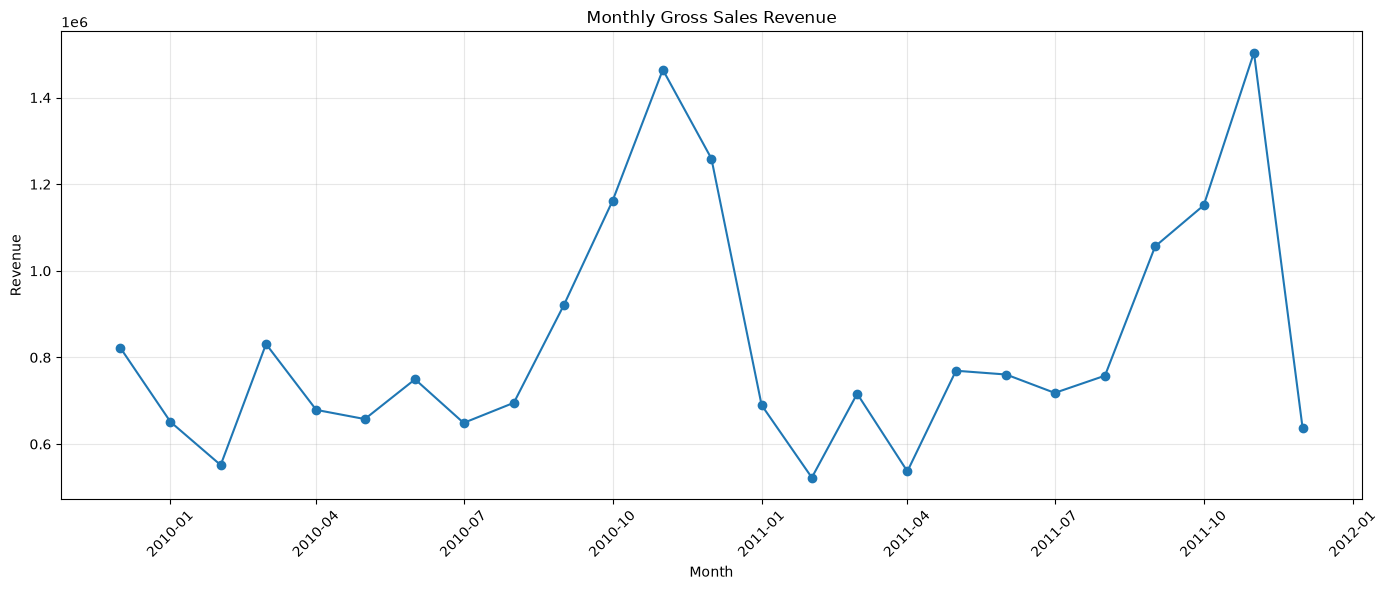

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["month"],
    monthly_summary["revenue"],
    marker="o",
)

plt.title("Monthly Gross Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_gross_sales_revenue.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

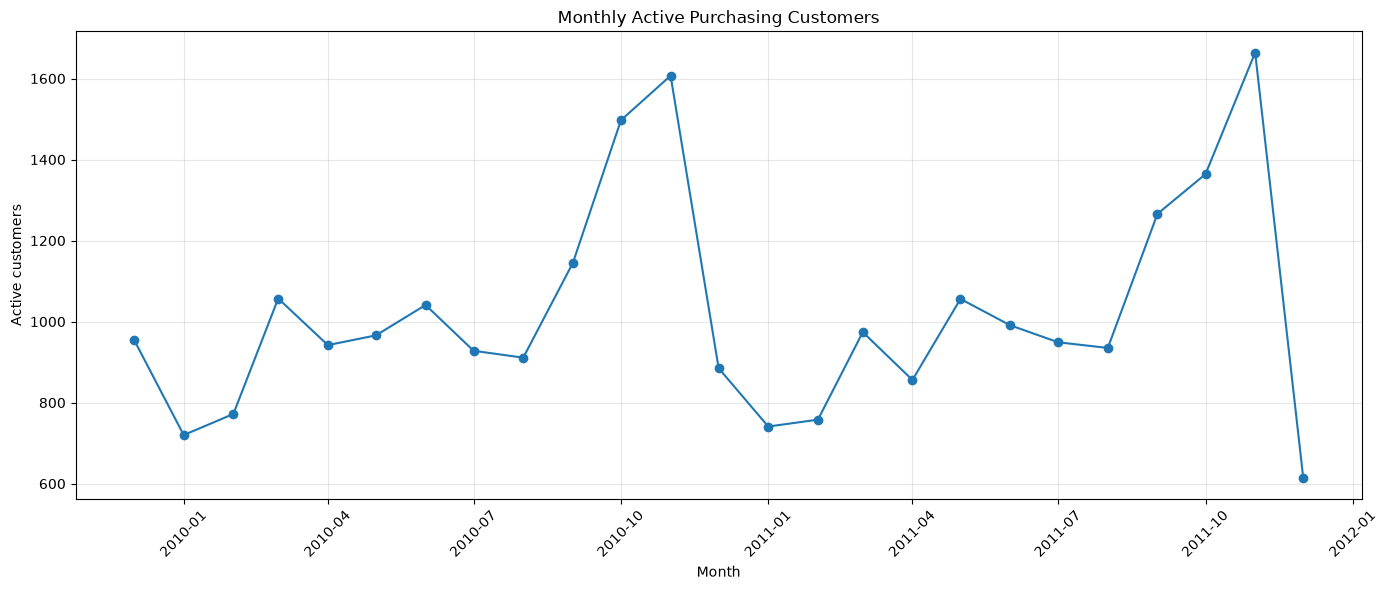

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["month"],
    monthly_summary["active_customers"],
    marker="o",
)

plt.title("Monthly Active Purchasing Customers")
plt.xlabel("Month")
plt.ylabel("Active customers")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_active_customers.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [11]:
country_summary = (
    sales.groupby(
        "country",
        observed=True,
    )
    .agg(
        revenue=("line_amount", "sum"),
        sales_rows=("invoice_key", "size"),
        orders=("invoice_key", "nunique"),
        customers=("customer_id", "nunique"),
        units_sold=("quantity", "sum"),
    )
    .reset_index()
)


country_summary["average_order_value"] = (
    country_summary["revenue"]
    / country_summary["orders"]
)


country_summary = country_summary.sort_values(
    "revenue",
    ascending=False,
).reset_index(drop=True)


display(country_summary.head(15))

,country,revenue,sales_rows,orders,customers,units_sold,average_order_value
0,United Kingdom,"17,814,055.93",946587,37309,5350,9349186,477.47
1,EIRE,"664,050.09",17329,636,5,340054,"1,044.10"
2,Netherlands,"554,230.69",5087,229,22,383976,"2,420.22"
3,Germany,"430,703.79",16670,804,107,227769,535.70
4,France,"356,746.51",13907,633,95,275090,563.58
5,Australia,"169,900.61",1811,97,15,104080,"1,751.55"
6,Spain,"109,127.21",3707,156,41,50774,699.53
7,Switzerland,"100,988.99",3128,94,22,52872,"1,074.35"
8,Sweden,"91,869.82",1336,105,19,88633,874.95
9,Denmark,"69,862.19",798,44,12,237925,"1,587.78"


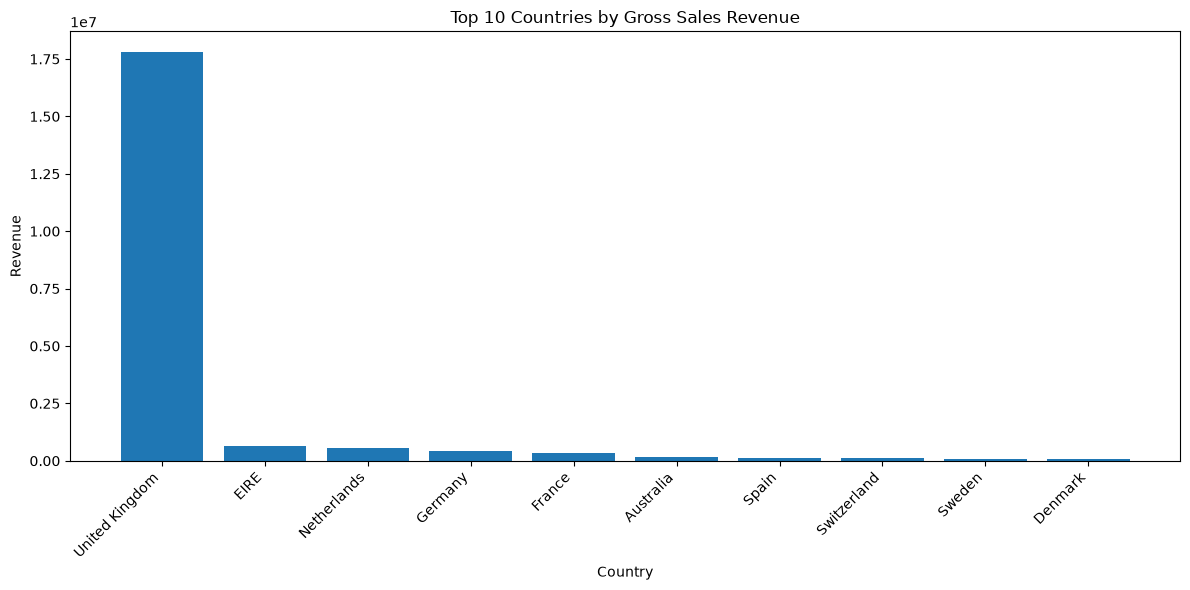

In [12]:
top_countries = country_summary.head(10)


plt.figure(figsize=(12, 6))

plt.bar(
    top_countries["country"],
    top_countries["revenue"],
)

plt.title("Top 10 Countries by Gross Sales Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_countries_by_revenue.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [13]:
product_summary = (
    sales.groupby(
        [
            "stock_code",
            "description",
        ],
        dropna=False,
        observed=True,
    )
    .agg(
        revenue=("line_amount", "sum"),
        units_sold=("quantity", "sum"),
        orders=("invoice_key", "nunique"),
        sales_rows=("invoice_key", "size"),
    )
    .reset_index()
)


product_summary = product_summary.sort_values(
    "revenue",
    ascending=False,
).reset_index(drop=True)


display(product_summary.head(20))

,stock_code,description,revenue,units_sold,orders,sales_rows
0,22423,REGENCY CAKESTAND 3 TIER,"344,069.30",27536,4007,4041
1,M,Manual,"340,342.68",9753,805,871
2,DOT,DOTCOM POSTAGE,"322,657.48",1436,1436,1436
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"266,582.35",96563,5571,5720
4,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1
5,85099B,JUMBO BAG RED RETROSPOT,"150,640.27",79117,3335,3379
6,47566,PARTY BUNTING,"149,109.35",28362,2698,2729
7,84879,ASSORTED COLOUR BIRD ORNAMENT,"131,817.81",81590,2867,2911
8,POST,POSTAGE,"127,597.42",5461,1886,1886
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"123,002.89",36534,2117,2168


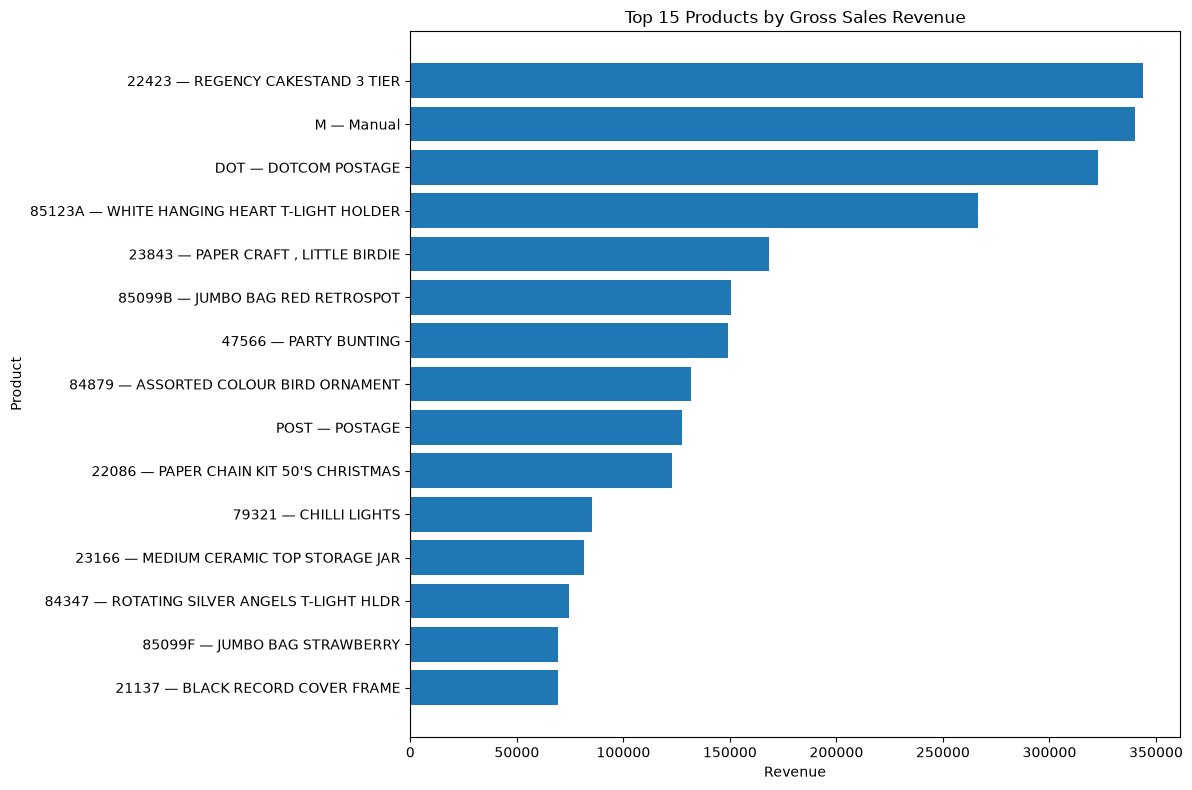

In [14]:
top_products = product_summary.head(15).copy()

top_products["product_label"] = (
    top_products["stock_code"].astype(str)
    + " — "
    + top_products["description"]
    .fillna("Unknown product")
    .astype(str)
    .str.slice(0, 45)
)


plt.figure(figsize=(12, 8))

plt.barh(
    top_products["product_label"][::-1],
    top_products["revenue"][::-1],
)

plt.title("Top 15 Products by Gross Sales Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_products_by_revenue.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [15]:
analysis_date = (
    customer_sales["invoice_date"].max()
    + pd.Timedelta(days=1)
)


customer_summary = (
    customer_sales.groupby(
        "customer_id",
        observed=True,
    )
    .agg(
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
        invoices=("invoice_key", "nunique"),
        total_spend=("line_amount", "sum"),
        total_units=("quantity", "sum"),
        unique_products=("stock_code", "nunique"),
        countries=("country", "nunique"),
    )
)


customer_summary["recency_days"] = (
    analysis_date
    - customer_summary["last_purchase"]
).dt.days


customer_summary["tenure_days"] = (
    customer_summary["last_purchase"]
    - customer_summary["first_purchase"]
).dt.days


customer_summary["average_order_value"] = (
    customer_summary["total_spend"]
    / customer_summary["invoices"]
)


customer_summary = customer_summary.sort_values(
    "total_spend",
    ascending=False,
)


display(customer_summary.head(15))

,first_purchase,last_purchase,invoices,total_spend,total_units,unique_products,countries,recency_days,tenure_days,average_order_value
customer_id,,,,,,,,,,
18102,2009-12-01 09:24:00,2011-12-09 11:50:00,149,"608,821.65",188340,382,1,1,738,"4,086.05"
14646,2009-12-02 16:52:00,2011-12-08 12:12:00,151,"528,602.52",367193,961,1,2,735,"3,500.68"
14156,2009-12-01 12:30:00,2011-11-30 10:54:00,157,"313,759.82",165873,1446,1,10,728,"1,998.47"
14911,2009-12-01 11:41:00,2011-12-08 15:54:00,406,"295,832.39",149949,2550,1,1,737,728.65
17450,2010-09-27 16:59:00,2011-12-01 13:29:00,53,"246,813.09",84700,144,1,8,429,"4,656.85"
13694,2009-12-04 15:26:00,2011-12-06 09:32:00,144,"196,482.81",189205,896,1,4,731,"1,364.46"
17511,2009-12-02 10:52:00,2011-12-07 10:12:00,62,"175,603.55",119656,657,1,3,734,"2,832.32"
16446,2011-05-18 09:52:00,2011-12-09 09:15:00,2,"168,472.50",80997,3,1,1,204,"84,236.25"
16684,2009-12-07 12:56:00,2011-12-05 14:06:00,55,"147,142.77",104810,184,1,4,728,"2,675.32"


In [16]:
customer_metrics = [
    "invoices",
    "total_spend",
    "total_units",
    "unique_products",
    "recency_days",
    "tenure_days",
    "average_order_value",
]


display(
    customer_summary[
        customer_metrics
    ].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    ).T
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
invoices,"5,878.00",6.42,13.39,1.00,1.00,3.00,7.00,14.00,21.00,46.23,406.00
total_spend,"5,878.00","3,008.75","14,731.92",2.95,345.12,887.39,"2,298.01","5,557.65","9,504.78","29,710.55","608,821.65"
total_units,"5,878.00","1,815.51","8,958.97",1.00,189.00,487.00,"1,369.00","3,215.80","5,427.20","17,491.68","367,193.00"
unique_products,"5,878.00",81.99,116.48,1.00,19.00,45.00,103.00,198.00,281.00,502.69,"2,550.00"
recency_days,"5,878.00",201.33,209.34,1.00,26.00,96.00,380.00,535.00,625.00,726.00,739.00
tenure_days,"5,878.00",273.02,258.81,0.00,0.00,220.50,511.00,667.00,712.00,732.00,738.00
average_order_value,"5,878.00",384.91,"1,214.14",2.95,176.67,279.04,413.78,631.32,889.99,"1,959.25","84,236.25"


In [17]:
return_value = abs(
    returns_and_reversals.loc[
        returns_and_reversals["line_amount"] < 0,
        "line_amount",
    ].sum()
)


return_summary = pd.Series(
    {
        "Cancelled rows": int(
            transactions["is_cancelled"].sum()
        ),
        "Negative quantity rows": int(
            transactions["is_negative_quantity"].sum()
        ),
        "Return or reversal rows": int(
            transactions["is_return_or_reversal"].sum()
        ),
        "Return or reversal invoices": int(
            returns_and_reversals["invoice_key"].nunique()
        ),
        "Negative return value": return_value,
        "Return value as percentage of gross sales": (
            return_value
            / gross_sales_revenue
            * 100
        ),
        "Rows requiring review": int(
            transactions["requires_review"].sum()
        ),
    },
    name="value",
)


display(return_summary.to_frame())

,value
Cancelled rows,"19,433.00"
Negative quantity rows,"22,889.00"
Return or reversal rows,"22,890.00"
Return or reversal invoices,"11,885.00"
Negative return value,"1,523,788.38"
Return value as percentage of gross sales,7.29
Rows requiring review,"25,629.00"


## Key Business Findings

### 1. The dataset provides substantial analytical coverage

After cleaning and exact deduplication, the dataset contains more than one
million transaction lines, 40,911 valid sales invoices, 5,878 identifiable
purchasing customers, 4,745 sold products, and transactions across 43
countries.

This scale is sufficient for customer segmentation, behavioral analysis,
churn modeling, and customer lifetime value estimation.

### 2. Revenue is likely concentrated among high-value orders and customers

Gross positive sales revenue is approximately 20.9 million. The average
invoice value is 511.20, while the median invoice value is only 301.88.

The average being substantially higher than the median indicates a
right-skewed invoice-value distribution. A relatively small number of large
orders are likely raising the overall average.

This suggests that later customer-segmentation models should account for
skewness and extreme values, potentially through logarithmic transformation
and robust scaling.

### 3. Returns and reversals represent a material business issue

Negative return value is approximately 1.52 million, equivalent to 7.29% of
gross positive sales revenue.

Returns should therefore not be treated only as a data-cleaning problem.
They represent meaningful customer behavior and may help identify:

- Customers with unusually high return activity.
- Product-quality or fulfillment issues.
- Revenue at risk.
- Potential predictors of future inactivity or churn.

### 4. Cancellation codes do not identify every reversed transaction

There are more return-or-reversal rows than explicitly cancelled rows.
This means that relying only on invoice numbers beginning with `C` would
underestimate returns.

The cleaning pipeline therefore defines a return or reversal using both
cancellation codes and negative quantities.

### 5. Separate analytical datasets are necessary

Transactions without customer identifiers remain valuable for overall
sales, product, country, and seasonality analysis. However, they cannot be
used for customer-level segmentation, churn prediction, or lifetime value
modeling.

For this reason, customer-level models will use identifiable customer
transactions, while general business reporting can use all valid sales.

### 6. Business interpretation must accompany predictive modeling

The project should not focus only on producing customer clusters or churn
probabilities. The final analysis must connect each result to a business
decision, such as:

- Which valuable customers require retention intervention?
- Which customers should receive loyalty benefits?
- Which customers generate high revenue but also high return costs?
- Which low-value inactive customers should not receive expensive offers?

In [18]:
monthly_summary.to_csv(
    REPORTS_DIR / "monthly_business_summary.csv",
    index=False,
)

country_summary.to_csv(
    REPORTS_DIR / "country_summary.csv",
    index=False,
)

product_summary.to_csv(
    REPORTS_DIR / "product_summary.csv",
    index=False,
)

customer_summary.to_parquet(
    PROJECT_ROOT
    / "data"
    / "interim"
    / "customer_eda_summary.parquet",
)


kpi_export = {
    "clean_transaction_rows": int(len(transactions)),
    "valid_sales_rows": int(len(sales)),
    "valid_sales_invoices": int(
        sales["invoice_key"].nunique()
    ),
    "known_purchasing_customers": int(
        customer_sales["customer_id"].nunique()
    ),
    "products_sold": int(
        sales["stock_code"].nunique()
    ),
    "countries": int(
        sales["country"].nunique()
    ),
    "gross_sales_revenue": float(
        gross_sales_revenue
    ),
    "negative_return_value": float(
        return_value
    ),
    "average_invoice_value": float(
        invoice_totals.mean()
    ),
    "median_invoice_value": float(
        invoice_totals.median()
    ),
    "minimum_invoice_date": str(minimum_date),
    "maximum_invoice_date": str(maximum_date),
}


(
    REPORTS_DIR
    / "data_understanding_kpis.json"
).write_text(
    json.dumps(
        kpi_export,
        indent=2,
    ),
    encoding="utf-8",
)


print("EDA outputs saved successfully.")
print(f"Reports: {REPORTS_DIR}")
print(f"Figures: {FIGURES_DIR}")

EDA outputs saved successfully.
Reports: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\reports
Figures: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\reports\figures


In [19]:
customer_concentration = (
    customer_summary
    .sort_values(
        "total_spend",
        ascending=False,
    )
    .copy()
)


customer_concentration["revenue_share"] = (
    customer_concentration["total_spend"]
    / customer_concentration["total_spend"].sum()
)


customer_concentration["cumulative_revenue_share"] = (
    customer_concentration["revenue_share"].cumsum()
)


number_of_customers = len(customer_concentration)


def top_customer_revenue_share(
    percentage: float,
) -> float:
    """Return the revenue share produced by the top customer percentage."""

    customer_count = max(
        1,
        int(np.ceil(number_of_customers * percentage)),
    )

    return (
        customer_concentration
        .head(customer_count)["total_spend"]
        .sum()
        / customer_concentration["total_spend"].sum()
        * 100
    )


concentration_summary = pd.Series(
    {
        "Number of purchasing customers": number_of_customers,
        "Top 1% customer revenue share": (
            top_customer_revenue_share(0.01)
        ),
        "Top 5% customer revenue share": (
            top_customer_revenue_share(0.05)
        ),
        "Top 10% customer revenue share": (
            top_customer_revenue_share(0.10)
        ),
        "Top 20% customer revenue share": (
            top_customer_revenue_share(0.20)
        ),
    },
    name="value",
)


display(concentration_summary.to_frame())

,value
Number of purchasing customers,"5,878.00"
Top 1% customer revenue share,32.02
Top 5% customer revenue share,52.07
Top 10% customer revenue share,64.01
Top 20% customer revenue share,77.32


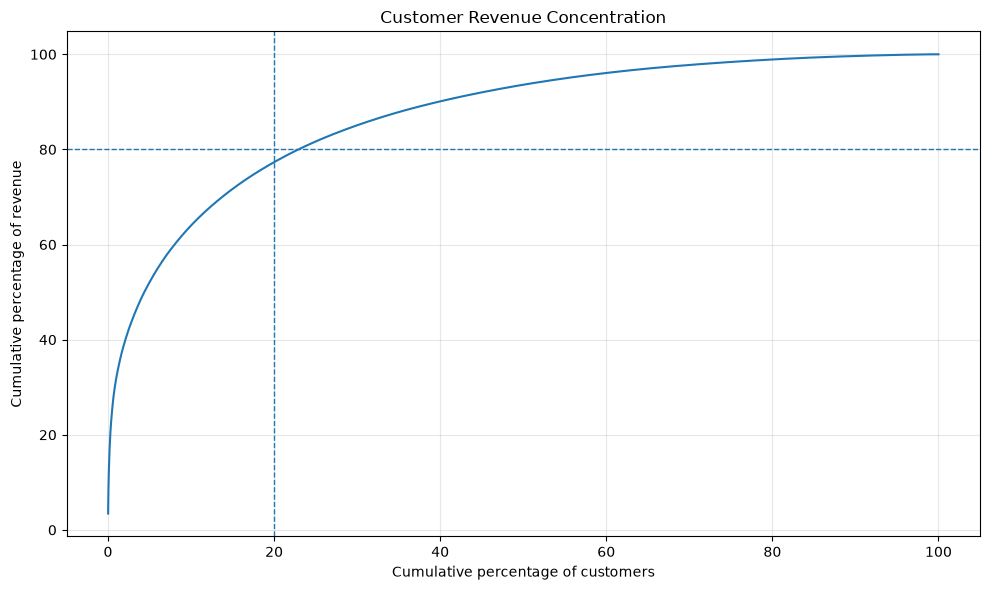

In [20]:
customer_concentration["customer_percentage"] = (
    np.arange(
        1,
        len(customer_concentration) + 1,
    )
    / len(customer_concentration)
    * 100
)


plt.figure(figsize=(10, 6))

plt.plot(
    customer_concentration["customer_percentage"],
    customer_concentration["cumulative_revenue_share"] * 100,
)

plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1,
)

plt.axvline(
    x=20,
    linestyle="--",
    linewidth=1,
)

plt.title("Customer Revenue Concentration")
plt.xlabel("Cumulative percentage of customers")
plt.ylabel("Cumulative percentage of revenue")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "customer_revenue_concentration.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [21]:
orders_per_customer = (
    customer_sales.groupby(
        "customer_id",
        observed=True,
    )["invoice_key"]
    .nunique()
)


repeat_customer_mask = orders_per_customer > 1


customer_frequency_summary = pd.Series(
    {
        "Purchasing customers": len(orders_per_customer),
        "One-time customers": int(
            (~repeat_customer_mask).sum()
        ),
        "Repeat customers": int(
            repeat_customer_mask.sum()
        ),
        "Repeat-customer rate (%)": float(
            repeat_customer_mask.mean() * 100
        ),
        "Average orders per customer": float(
            orders_per_customer.mean()
        ),
        "Median orders per customer": float(
            orders_per_customer.median()
        ),
        "Maximum orders by one customer": int(
            orders_per_customer.max()
        ),
    },
    name="value",
)


display(customer_frequency_summary.to_frame())

,value
Purchasing customers,"5,878.00"
One-time customers,"1,601.00"
Repeat customers,"4,277.00"
Repeat-customer rate (%),72.76
Average orders per customer,6.42
Median orders per customer,3.00
Maximum orders by one customer,406.00


In [22]:
anonymous_sales_revenue = sales.loc[
    sales["customer_id"].isna(),
    "line_amount",
].sum()


known_customer_revenue = sales.loc[
    sales["customer_id"].notna(),
    "line_amount",
].sum()


customer_identification_summary = pd.Series(
    {
        "Known-customer sales revenue": known_customer_revenue,
        "Anonymous sales revenue": anonymous_sales_revenue,
        "Known-customer revenue share (%)": (
            known_customer_revenue
            / gross_sales_revenue
            * 100
        ),
        "Anonymous revenue share (%)": (
            anonymous_sales_revenue
            / gross_sales_revenue
            * 100
        ),
    },
    name="value",
)


display(customer_identification_summary.to_frame())

,value
Known-customer sales revenue,"17,685,460.64"
Anonymous sales revenue,"3,228,430.83"
Known-customer revenue share (%),84.56
Anonymous revenue share (%),15.44


## Additional Customer Insights

### Revenue is highly concentrated among a small customer group

Customer revenue is strongly concentrated. The top 1% of purchasing
customers generate approximately 32.02% of known-customer revenue, while
the top 10% generate 64.01% and the top 20% generate 77.32%.

This concentration demonstrates why customer-level prioritization is
necessary. Losing a small number of high-value customers could have a
disproportionately large effect on revenue.

### Most customers make repeat purchases

Approximately 72.76% of purchasing customers completed more than one
order, while 1,601 customers purchased only once.

The high repeat-customer rate makes the dataset suitable for behavioral
segmentation, retention analysis, and purchase-frequency modeling.

However, the average number of orders per customer is 6.42, compared with
a median of only 3. This difference, together with a maximum of 406 orders,
shows that customer activity is highly skewed and includes a small number
of exceptionally frequent buyers.

### Most revenue can be connected to identifiable customers

Approximately 84.56% of gross sales revenue belongs to transactions with
known customer identifiers. This provides strong coverage for RFM
segmentation, churn prediction, and customer lifetime value analysis.

The remaining 15.44% of anonymous revenue remains useful for general
sales and product analysis, but cannot be assigned to individual
customer-level models.